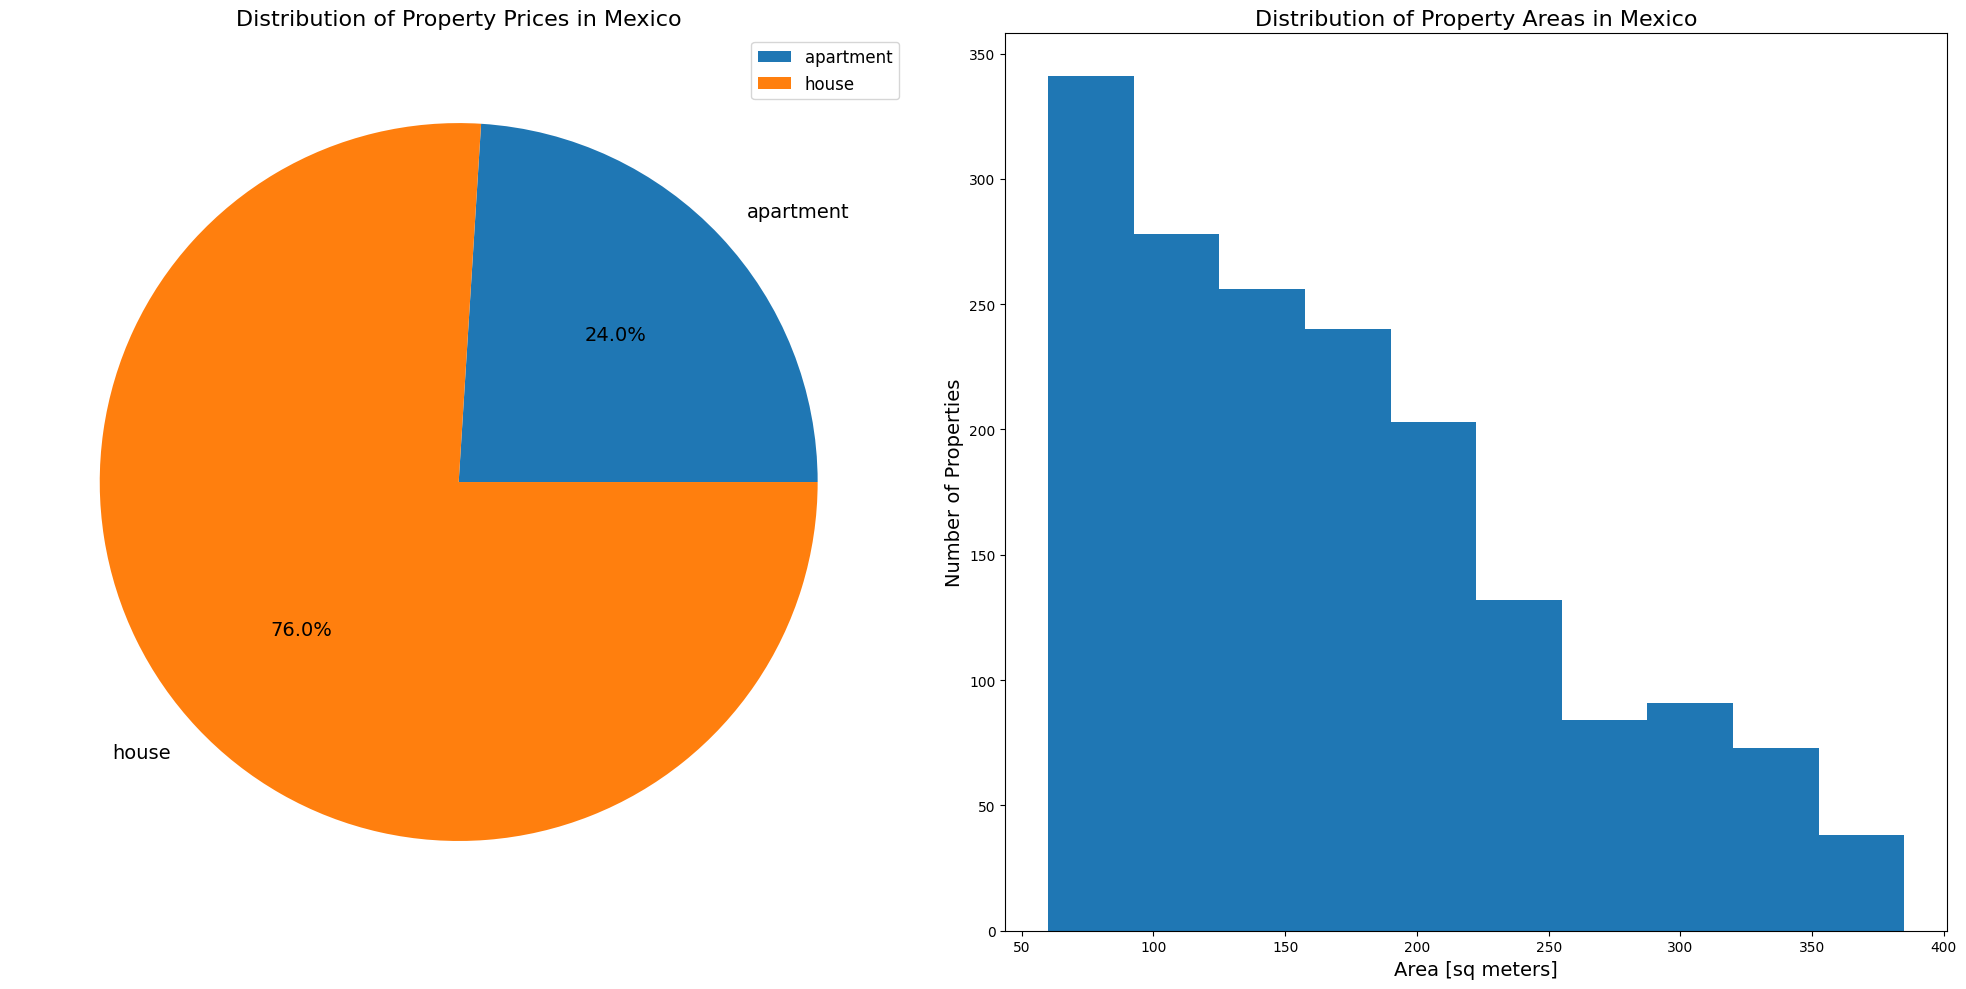

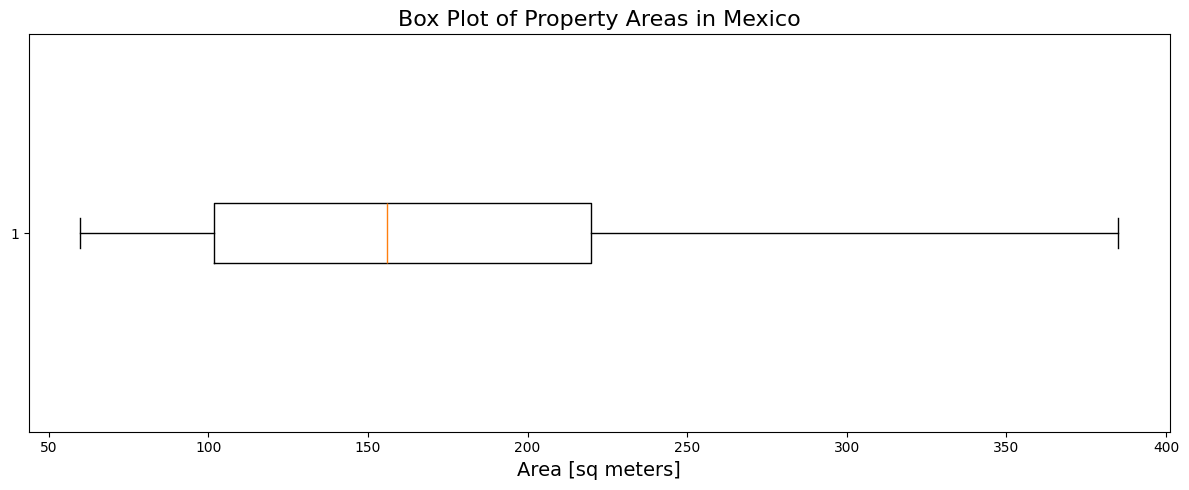

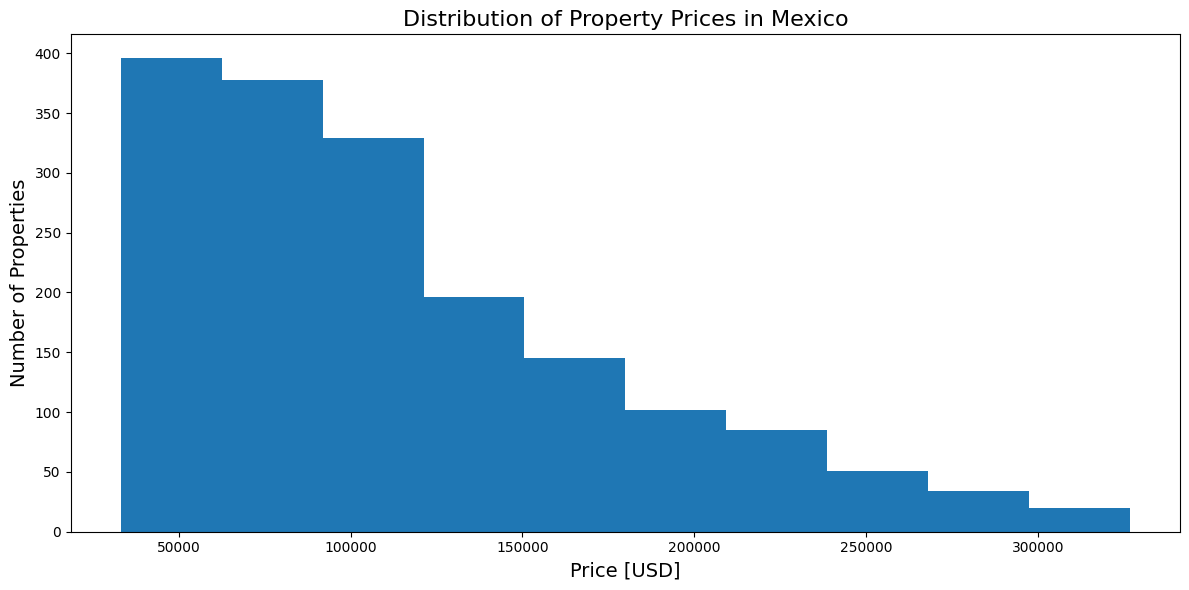

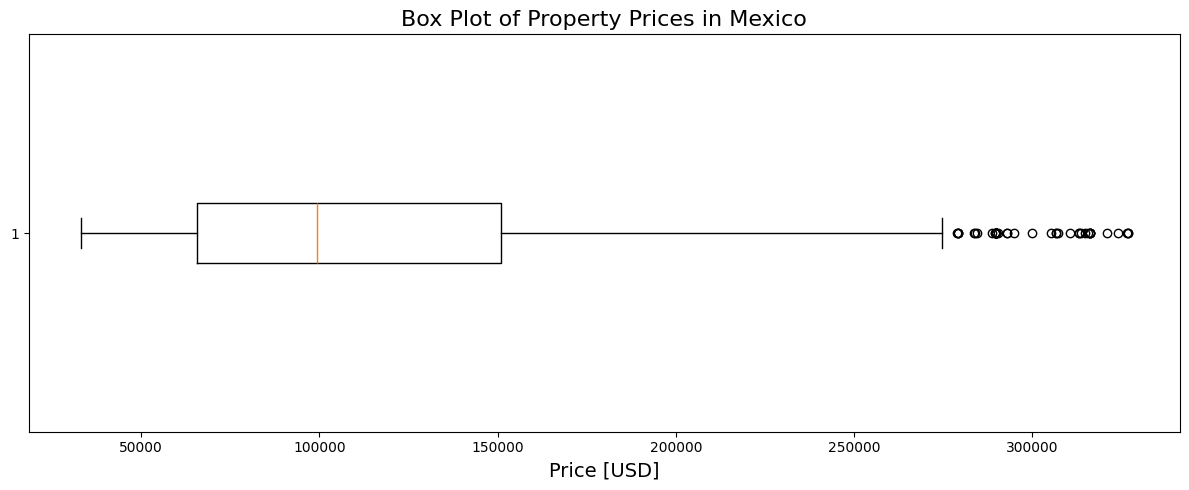

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv('mexico-real-estate-combined.csv')

plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.pie(
    df.groupby('property_type')['price_usd'].sum(),
    labels=df.groupby('property_type')['price_usd'].sum().index,
    autopct='%1.1f%%',
    textprops={'fontsize': 14}
)
plt.legend(fontsize=12)
plt.title('Distribution of Property Prices in Mexico', fontsize=16)

plt.subplot(1, 2, 2)
plt.hist(df["area_m2"])
plt.title('Distribution of Property Areas in Mexico', fontsize=16)
plt.xlabel('Area [sq meters]', fontsize=14)
plt.ylabel('Number of Properties', fontsize=14)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.boxplot(df['area_m2'], vert=False)
plt.title('Box Plot of Property Areas in Mexico', fontsize=16)
plt.xlabel('Area [sq meters]', fontsize=14)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

plt.hist(df["price_usd"])
plt.title('Distribution of Property Prices in Mexico', fontsize=16)
plt.xlabel('Price [USD]', fontsize=14)
plt.ylabel('Number of Properties', fontsize=14)


plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.boxplot(df['price_usd'], vert=False)
plt.title('Box Plot of Property Prices in Mexico', fontsize=16)
plt.xlabel('Price [USD]', fontsize=14)

plt.tight_layout()
plt.show()

fig = px.scatter_map(
    df,
    lat='lat',
    lon='lon',
    color='price_usd',
    size='price_usd',
    hover_name='property_type',
    title='Geographical Distribution of Property Prices in Mexico'
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()

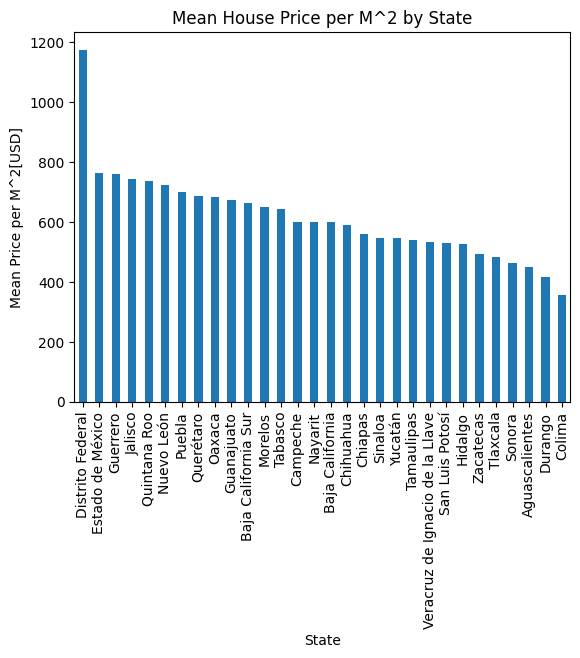

In [3]:
df['price_per_m2'] = df['price_usd'] / df['area_m2']


price_per_m2 = df.groupby("state")["price_per_m2"].mean().sort_values(ascending=False)
price_per_m2.plot(
    kind="bar",
    xlabel="State",
    ylabel="Mean Price per M^2[USD]",
    title="Mean House Price per M^2 by State"
);


Slope: 475.32027684984917, Intercept: 34403.227592386334, Correlation: 0.5855182453232062 R-squared: 0.34283161560636627


Text(0, 0.5, 'Price [USD]')

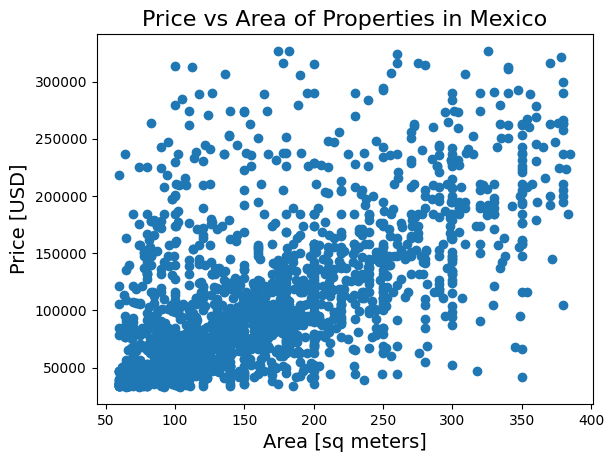

In [63]:
from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(df['area_m2'], df['price_usd'])
print(f"Slope: {slope}, Intercept: {intercept}, Correlation: {r_value} R-squared: {r_value**2}")


plt.scatter(df['area_m2'], df['price_usd'])
plt.title('Price vs Area of Properties in Mexico', fontsize=16)
plt.xlabel('Area [sq meters]', fontsize=14)
plt.ylabel('Price [USD]', fontsize=14)

(303, 7)
Correlation of 'area_m2' and 'price_usd' (Mexico City): 0.4107039213071789


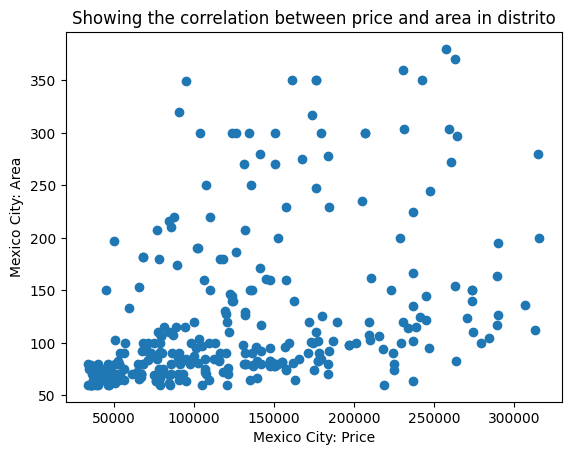

In [6]:
df_mexico_city = df[df["state"] == "Distrito Federal"]

df_mexico_city = df_mexico_city[df_mexico_city["area_m2"] < 1000]
print(df_mexico_city.shape)

plt.scatter(df_mexico_city["price_usd"], df_mexico_city["area_m2"])  
plt.xlabel("Mexico City: Price") 
plt.ylabel("Mexico City: Area") 
plt.title("Showing the correlation between price and area in distrito") 

p_correlation = df_mexico_city["price_usd"].corr(df_mexico_city["area_m2"])

print("Correlation of 'area_m2' and 'price_usd' (Mexico City):", p_correlation)